# Preprocessing and Visualization for New `data/` Catalogs

Based on `notebooks/preprocessing_pnr.ipynb`, this notebook is designed for newly added triplet datasets (`*_Eq.csv`, `*_Inj.csv`, `*_Head.json`) and provides:

- Batch loading and column standardization
- Construction of a unified minute-level injection time series
- Event catalog quality checks and summary statistics
- Batch export of processed outputs to each dataset’s `processed/` directory
- Single-dataset visualization (injection/pressure/seismic counts/magnitude and spatial distribution)


## 1) Setup and data discovery

In [1]:
from __future__ import annotations

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.max_columns = 100
plt.style.use("seaborn-v0_8-whitegrid")


def resolve_project_root() -> Path:
    """Return the project root that contains both `src/` and `data/`."""
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing both 'src' and 'data'.")


PROJECT_ROOT = resolve_project_root()
DATA_ROOT = PROJECT_ROOT / "data"
RAW_SUBDIR = "raw"


def dataset_data_dir(dataset_dir: Path) -> Path:
    """Return the raw data directory when it exists, otherwise the dataset directory."""
    raw_dir = dataset_dir / RAW_SUBDIR
    return raw_dir if raw_dir.exists() else dataset_dir


def discover_triplet_datasets(data_root: Path) -> list[str]:
    """Discover datasets that include EQ/Inj CSV files and a Head JSON file."""
    datasets: list[str] = []
    for d in sorted(data_root.iterdir()):
        if not d.is_dir():
            continue
        name = d.name
        base = dataset_data_dir(d)
        has_eq = (base / f"{name}_Eq.csv").exists()
        has_inj = (base / f"{name}_Inj.csv").exists()
        has_head = (base / f"{name}_Head.json").exists()
        if has_eq and has_inj and has_head:
            datasets.append(name)
    return datasets


DATASETS = discover_triplet_datasets(DATA_ROOT)

PROCESS_DATASETS = DATASETS.copy()

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Found {len(DATASETS)} triplet datasets:")
print(DATASETS)
print(f"Will process {len(PROCESS_DATASETS)} datasets:")
print(PROCESS_DATASETS)

PROJECT_ROOT: /home/yzzhang/pjt/chuandian_eq
Found 12 triplet datasets:
['Basel', 'CB_HAB1a', 'CB_HAB1b', 'CB_HAB4', 'FORGE2022', 'SSFS1993', 'SSFS2000', 'SSFS2003', 'SSFS2004', 'SSFS2005', 'St1-2018', 'St1-2020']
Will process 12 datasets:
['Basel', 'CB_HAB1a', 'CB_HAB1b', 'CB_HAB4', 'FORGE2022', 'SSFS1993', 'SSFS2000', 'SSFS2003', 'SSFS2004', 'SSFS2005', 'St1-2018', 'St1-2020']


## 2) Helper functions

In [2]:
EQ_RENAME = {
    "Time (ISO)": "time_iso",
    "Inter-event Time (min)": "inter_event_min",
    "Magnitude (M)": "magnitude",
    "Latitude (deg)": "latitude",
    "Longitude (deg)": "longitude",
    "Depth (m)": "depth_m",
}

INJ_RENAME = {
    "Time (ISO)": "time_iso",
    "Injection Rate (m3/min)": "inj_rate_m3_min",
    "Pressure (MPa)": "pressure_mpa",
}

HEAD_RENAME = {
    "Mc": "mc",
    "dMb": "dmb",
    "dMd": "dmd",
}

# Rule: SSFS* -> 5 min, others -> 1 min
DEFAULT_RESAMPLE_MIN = 1
PREFIX_RESAMPLE_MIN = {
    "SSFS": 5,
}

# Time snapping tolerance for float precision correction
TIME_SNAP_ATOL_MIN = 5e-6

# If native_dt > target_dt * (1 + UPSAMPLE_REL_TOL), treat as upsample
UPSAMPLE_REL_TOL = 1e-3



def get_resample_freq_min(dataset: str) -> int:
    """Choose resampling frequency in minutes from dataset naming rules."""
    ds = dataset.upper()
    for prefix, freq in PREFIX_RESAMPLE_MIN.items():
        if ds.startswith(prefix.upper()):
            return int(freq)
    return int(DEFAULT_RESAMPLE_MIN)


def to_rule(freq_min: int) -> str:
    """Convert minute frequency to a pandas resample rule string."""
    return f"{int(freq_min)}min"


def read_csv_table(path: Path) -> pd.DataFrame:
    """Read a CSV file and normalize column-name whitespace."""
    df = pd.read_csv(path, low_memory=False)
    df.columns = [str(c).strip() for c in df.columns]
    return df

def read_head_json(path: Path) -> pd.DataFrame:
    """Load head metadata JSON and return a one-row numeric DataFrame."""
    payload = json.loads(path.read_text(encoding="utf-8"))
    missing = [raw_key for raw_key in HEAD_RENAME if raw_key not in payload]
    if missing:
        raise KeyError(f"Missing required head metadata keys: {missing}")

    out = {}
    for raw_key, out_key in HEAD_RENAME.items():
        out[out_key] = pd.to_numeric(payload[raw_key], errors="raise")
    return pd.DataFrame([out])

def format_datetime_iso(series: pd.Series) -> pd.Series:
    """Format timestamps as compact ISO strings while preserving missing values."""
    ts = pd.to_datetime(series)
    out = ts.dt.strftime("%Y-%m-%dT%H:%M:%S.%f")
    out = out.str.rstrip("0").str.rstrip(".")
    return out.where(ts.notna(), None)


def standardize_table(
    df: pd.DataFrame,
    rename_map: dict[str, str],
) -> pd.DataFrame:
    """Rename source columns and enforce strict schema/types."""
    missing = [c for c in rename_map if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    out = df.rename(columns=rename_map).copy()
    out = out[list(rename_map.values())]

    if "time_iso" not in out.columns:
        raise KeyError("Missing required column 'time_iso' after standardization.")

    out["time_iso"] = out["time_iso"].astype("string").str.strip()
    out["time_iso"] = out["time_iso"].where(~out["time_iso"].isin(["", "nan", "NaN", "NaT"]), pd.NA)
    out["time_iso"] = pd.to_datetime(out["time_iso"], format="mixed", errors="raise", utc=True).dt.tz_convert(None)
    if out["time_iso"].isna().any():
        bad = out.index[out["time_iso"].isna()][:10].tolist()
        raise ValueError(f"Found missing/invalid time_iso values at rows {bad}.")

    for col in out.columns:
        if col in {"time_iso"}:
            continue
        out[col] = pd.to_numeric(out[col], errors="raise")

    return out

def load_raw_triplet(dataset: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load and standardize EQ, injection, and head tables for one dataset."""
    root = dataset_data_dir(DATA_ROOT / dataset)
    eq = standardize_table(read_csv_table(root / f"{dataset}_Eq.csv"), EQ_RENAME)
    inj = standardize_table(read_csv_table(root / f"{dataset}_Inj.csv"), INJ_RENAME)
    head = read_head_json(root / f"{dataset}_Head.json")
    return eq, inj, head


def infer_time_origin(eq: pd.DataFrame, inj: pd.DataFrame) -> pd.Timestamp:
    """Infer shared absolute origin strictly from `time_iso`."""
    if "time_iso" not in eq.columns or "time_iso" not in inj.columns:
        raise KeyError("Both EQ and INJ tables must contain 'time_iso'.")

    eq_iso = pd.to_datetime(eq["time_iso"], format="mixed", errors="raise", utc=True).dt.tz_convert(None)
    inj_iso = pd.to_datetime(inj["time_iso"], format="mixed", errors="raise", utc=True).dt.tz_convert(None)

    all_iso = pd.concat([eq_iso, inj_iso], ignore_index=True)
    if all_iso.isna().any():
        bad = all_iso.index[all_iso.isna()][:10].tolist()
        raise ValueError(f"Found missing/invalid time_iso values when inferring origin at rows {bad}.")

    return pd.Timestamp(all_iso.min()).round("ms")

def attach_time_columns(df: pd.DataFrame, origin_ts: pd.Timestamp) -> pd.DataFrame:
    """Populate `time_min`, `time_iso`, and `ts` using strict `time_iso` parsing."""
    if origin_ts is None:
        raise ValueError("origin_ts cannot be None.")

    out = df.copy()
    if "time_iso" not in out.columns:
        raise KeyError("Missing required column 'time_iso'.")

    out["time_iso"] = pd.to_datetime(out["time_iso"], format="mixed", errors="raise", utc=True).dt.tz_convert(None)
    if out["time_iso"].isna().any():
        bad = out.index[out["time_iso"].isna()][:10].tolist()
        raise ValueError(f"Found missing/invalid time_iso values at rows {bad}.")

    out["time_min"] = ((out["time_iso"] - origin_ts) / pd.Timedelta(minutes=1)).astype(float)
    if not np.isfinite(out["time_min"]).all():
        bad = out.index[~np.isfinite(out["time_min"])][:10].tolist()
        raise ValueError(f"Found non-finite time_min values at rows {bad}.")

    out["ts"] = out["time_iso"]
    return out

def resolve_minute_bounds(
    eq: pd.DataFrame,
    inj: pd.DataFrame,
    origin_ts: pd.Timestamp,
) -> tuple[int, int]:
    """Compute integer minute bounds from EQ/INJ `time_iso` values."""
    if origin_ts is None:
        raise ValueError("origin_ts cannot be None.")

    if "time_iso" not in eq.columns or "time_iso" not in inj.columns:
        raise KeyError("Both EQ and INJ tables must contain 'time_iso'.")

    eq_iso = pd.to_datetime(eq["time_iso"], format="mixed", errors="raise", utc=True).dt.tz_convert(None)
    inj_iso = pd.to_datetime(inj["time_iso"], format="mixed", errors="raise", utc=True).dt.tz_convert(None)

    eq_min = ((eq_iso - origin_ts) / pd.Timedelta(minutes=1)).to_numpy(dtype=float)
    inj_min = ((inj_iso - origin_ts) / pd.Timedelta(minutes=1)).to_numpy(dtype=float)

    if eq_min.size == 0 or inj_min.size == 0:
        raise ValueError("EQ/INJ tables must both contain at least one row.")
    if not np.isfinite(eq_min).all():
        bad = np.where(~np.isfinite(eq_min))[0][:10].tolist()
        raise ValueError(f"Found non-finite EQ time_iso-derived minutes at rows {bad}.")
    if not np.isfinite(inj_min).all():
        bad = np.where(~np.isfinite(inj_min))[0][:10].tolist()
        raise ValueError(f"Found non-finite INJ time_iso-derived minutes at rows {bad}.")

    start = int(np.floor(min(eq_min.min(), inj_min.min())))
    end = int(np.ceil(min(eq_min.max(), inj_min.max())))
    return start, end

def make_time_grid(start_min: int, end_min: int, freq_min: int) -> tuple[np.ndarray, pd.TimedeltaIndex]:
    """Build aligned minute grid arrays for the target resampling frequency."""
    if freq_min <= 0:
        raise ValueError(f"freq_min must be positive, got {freq_min}")

    start_bin = int(np.floor(start_min / freq_min) * freq_min)
    end_bin = int(np.floor(end_min / freq_min) * freq_min)
    grid_min = np.arange(start_bin, end_bin + freq_min, freq_min, dtype=np.int64)
    grid_td = pd.to_timedelta(grid_min, unit="m")
    grid_td.name = "ts"
    return grid_min, grid_td


def estimate_native_step_min(inj: pd.DataFrame) -> float:
    """Estimate native injection sampling step (minutes) from `time_iso` spacing."""
    if "time_iso" not in inj.columns:
        raise KeyError("INJ table must contain 'time_iso'.")

    ts = pd.to_datetime(inj["time_iso"], format="mixed", errors="raise", utc=True).dt.tz_convert(None)
    t = (ts.astype("int64") / 1e9 / 60.0).to_numpy(dtype=float)
    if t.size < 2:
        raise ValueError("INJ table must contain at least 2 rows.")
    if not np.isfinite(t).all():
        bad = np.where(~np.isfinite(t))[0][:10].tolist()
        raise ValueError(f"Found non-finite INJ time_iso minute values at rows {bad}.")

    t = np.sort(np.unique(t))
    dt = np.diff(t)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if dt.size == 0:
        raise ValueError("INJ time_iso has no positive spacing; cannot estimate native step.")

    return float(np.median(dt))

def snap_time_to_resample_grid_minutes(t: np.ndarray, freq_min: int) -> np.ndarray:
    """Snap near-grid minute values to reduce floating-point drift before resampling."""
    if freq_min <= 0:
        return t

    step = float(freq_min)
    snapped = np.rint(t / step) * step
    atol = max(TIME_SNAP_ATOL_MIN, abs(step) * 1e-6)
    out = np.where(np.abs(t - snapped) <= atol, snapped, t)
    return out


def build_injection_frame(
    inj: pd.DataFrame,
    start_min: int,
    end_min: int,
    freq_min: int,
    native_step_min: float,
    origin_ts: pd.Timestamp,
) -> tuple[pd.DataFrame, bool, str]:
    """Resample injection and pressure onto the target grid and derive clean rate features."""
    if origin_ts is None:
        raise ValueError("origin_ts cannot be None.")

    rule = to_rule(freq_min)
    _, grid_td = make_time_grid(start_min, end_min, freq_min)

    inj_ts = inj.copy()
    inj_ts["time_iso"] = pd.to_datetime(inj_ts["time_iso"], format="mixed", errors="raise", utc=True).dt.tz_convert(None)
    t_raw = ((inj_ts["time_iso"] - origin_ts) / pd.Timedelta(minutes=1)).to_numpy(dtype=float)
    if not np.isfinite(t_raw).all():
        bad = np.where(~np.isfinite(t_raw))[0][:10].tolist()
        raise ValueError(f"Found non-finite INJ time_iso-derived minutes at rows {bad}.")

    t_snap = snap_time_to_resample_grid_minutes(t_raw, freq_min)
    inj_ts["time_min_snap"] = t_snap
    inj_ts["ts"] = pd.to_timedelta(inj_ts["time_min_snap"], unit="m")

    inj_ts = (
        inj_ts.sort_values("ts")
        .groupby("ts", as_index=False)[["inj_rate_m3_min", "pressure_mpa"]]
        .mean(numeric_only=True)
        .set_index("ts")
    )

    is_upsample = bool(np.isfinite(native_step_min) and (native_step_min > freq_min * (1.0 + UPSAMPLE_REL_TOL)))

    if is_upsample:
        # Keep step-wise behavior when target grid is finer than source sampling.
        inj_rs = inj_ts.resample(rule).ffill()
        inj_rs = inj_rs.reindex(grid_td).ffill()
        fill_policy = "upsample_ffill"
    else:
        inj_rs = inj_ts.resample(rule).mean()
        inj_rs = inj_rs.reindex(grid_td)
        fill_policy = "aggregate_mean"

    inj_rs["inj_rate_m3_min"] = inj_rs["inj_rate_m3_min"].fillna(0.0)
    inj_rs["pressure_mpa"] = inj_rs["pressure_mpa"].ffill().fillna(0.0)

    inj_rs.index.name = "ts"
    inj_rs["time_iso"] = origin_ts + inj_rs.index
    inj_rs["time_min"] = ((inj_rs["time_iso"] - origin_ts) / pd.Timedelta(minutes=1)).astype(float)

    return inj_rs, is_upsample, fill_policy

def build_eq_features(
    eq: pd.DataFrame,
    start_min: int,
    end_min: int,
    freq_min: int,
    origin_ts: pd.Timestamp,
) -> tuple[pd.DataFrame, pd.Series]:
    """Prepare EQ event features and compute per-bin seismicity counts."""
    if origin_ts is None:
        raise ValueError("origin_ts cannot be None.")

    rule = to_rule(freq_min)
    _, grid_td = make_time_grid(start_min, end_min, freq_min)

    eq_proc = eq.copy().sort_values("time_iso").reset_index(drop=True)
    eq_proc["time_iso"] = pd.to_datetime(eq_proc["time_iso"], format="mixed", errors="raise", utc=True).dt.tz_convert(None)
    eq_proc["time_min"] = ((eq_proc["time_iso"] - origin_ts) / pd.Timedelta(minutes=1)).astype(float)

    t_arr = eq_proc["time_min"].to_numpy(dtype=float)
    if not np.isfinite(t_arr).all():
        bad = np.where(~np.isfinite(t_arr))[0][:10].tolist()
        raise ValueError(f"Found non-finite EQ time_iso-derived minutes at rows {bad}.")

    eq_proc["ts"] = eq_proc["time_iso"]

    if len(eq_proc) > 0:
        eq_proc["inter_event_min_recalc"] = (eq_proc["time_iso"].diff() / pd.Timedelta(minutes=1)).astype(float)
        eq_proc.loc[0, "inter_event_min_recalc"] = float((eq_proc.loc[0, "time_iso"] - origin_ts) / pd.Timedelta(minutes=1))
        eq_proc["inter_event_min_recalc"] = eq_proc["inter_event_min_recalc"].clip(lower=0.0)
    else:
        eq_proc["inter_event_min_recalc"] = pd.Series(dtype=float)

    start_ts = origin_ts + pd.to_timedelta(start_min, unit="m")
    end_ts = origin_ts + pd.to_timedelta(end_min, unit="m")
    eq_window = eq_proc[(eq_proc["time_iso"] >= start_ts) & (eq_proc["time_iso"] <= end_ts)].copy()
    if len(eq_window) > 0:
        # Align event times to the target grid before counting to avoid label mismatches.
        eq_window["ts_rel"] = (eq_window["time_iso"] - origin_ts).dt.floor(rule)
        eq_count = eq_window.groupby("ts_rel").size().reindex(grid_td, fill_value=0)
    else:
        eq_count = pd.Series(0, index=grid_td)

    eq_count = eq_count.astype(np.int32)
    eq_count.index.name = "ts"

    return eq_proc, eq_count

def preprocess_dataset(dataset: str, save_outputs: bool = True, return_frames: bool = False):
    """Run end-to-end preprocessing for one dataset and optionally save outputs."""
    eq, inj, head = load_raw_triplet(dataset)
    if eq.empty:
        raise ValueError("EQ table is empty.")
    if inj.empty:
        raise ValueError("INJ table is empty.")
    if head.empty:
        raise ValueError("Head metadata table is empty.")

    eq_total_before_mag_drop = int(len(eq))
    eq["magnitude"] = pd.to_numeric(eq["magnitude"], errors="coerce")
    valid_mag_mask = np.isfinite(eq["magnitude"].to_numpy(dtype=float))
    n_eq_dropped_missing_mag = int((~valid_mag_mask).sum())
    if n_eq_dropped_missing_mag > 0:
        eq = eq.loc[valid_mag_mask].copy().reset_index(drop=True)
    if eq.empty:
        raise ValueError("All EQ rows were dropped due to missing/non-finite magnitude.")

    origin_ts = infer_time_origin(eq, inj)
    eq = attach_time_columns(eq, origin_ts)
    inj = attach_time_columns(inj, origin_ts)

    start_min, end_min = resolve_minute_bounds(eq, inj, origin_ts)
    freq_min = get_resample_freq_min(dataset)
    native_step_min = estimate_native_step_min(inj)

    eq_proc, eq_count = build_eq_features(eq, start_min, end_min, freq_min, origin_ts)
    inj_rs, is_upsample, inj_fill_policy = build_injection_frame(
        inj=inj,
        start_min=start_min,
        end_min=end_min,
        freq_min=freq_min,
        native_step_min=native_step_min,
        origin_ts=origin_ts,
    )

    inj_rs["eq_count"] = eq_count.values
    inj_rs["eq_cum_count"] = inj_rs["eq_count"].cumsum()

    start_ts = origin_ts + pd.to_timedelta(start_min, unit="m")
    end_ts = origin_ts + pd.to_timedelta(end_min, unit="m")

    head_row = head.iloc[0]

    summary = {
        "dataset": dataset,
        "resample_freq_min": int(freq_min),
        "resample_rule": to_rule(freq_min),
        "native_step_min": float(native_step_min) if np.isfinite(native_step_min) else None,
        "is_upsample": bool(is_upsample),
        "inj_fill_policy": inj_fill_policy,
        "mc": float(head_row["mc"]),
        "dmb": float(head_row["dmb"]),
        "dmd": float(head_row["dmd"]),
        "start_min": int(start_min),
        "end_min": int(end_min),
        "start_time_iso": start_ts.isoformat(),
        "end_time_iso": end_ts.isoformat(),
        "time_origin_iso": origin_ts.isoformat(),
        "duration_day": float((end_min - start_min) / (60 * 24)),
        "n_eq": int(len(eq_proc)),
        "n_eq_dropped_missing_mag": int(n_eq_dropped_missing_mag),
        "n_eq_duplicate_time": int(eq_proc["time_iso"].duplicated().sum()),
        "n_inj_raw": int(len(inj)),
        "n_inj_resampled": int(len(inj_rs)),
        "eq_missing_mag_ratio": float(n_eq_dropped_missing_mag / eq_total_before_mag_drop),
        "eq_missing_latlon_ratio": float(eq_proc[["latitude", "longitude"]].isna().any(axis=1).mean()),
        "inj_negative_ratio_raw": float((inj["inj_rate_m3_min"] < 0).mean()),
        "inj_nonzero_ratio_resampled": float((inj_rs["inj_rate_m3_min"] > 0).mean()),
        "max_inj_rate_raw": float(inj["inj_rate_m3_min"].max(skipna=True)),
        "max_pressure_raw": float(inj["pressure_mpa"].max(skipna=True)),
    }

    output_paths = {}
    if save_outputs:
        out_dir = DATA_ROOT / dataset / "processed"
        out_dir.mkdir(parents=True, exist_ok=True)

        eq_out = out_dir / f"{dataset}_eq_processed.csv"
        inj_out = out_dir / f"{dataset}_inj_{freq_min}min_processed.csv"
        summary_out = out_dir / f"{dataset}_summary.json"

        eq_to_save = eq_proc.copy()
        eq_to_save["time_iso"] = format_datetime_iso(eq_to_save["time_iso"])
        eq_to_save["ts"] = format_datetime_iso(eq_to_save["ts"])

        inj_to_save = inj_rs[[
            "time_min",
            "time_iso",
            "inj_rate_m3_min",
            "pressure_mpa",
            "eq_count",
            "eq_cum_count",
        ]].copy()
        inj_to_save["time_iso"] = format_datetime_iso(inj_to_save["time_iso"])

        eq_to_save.to_csv(eq_out, index=False)
        inj_to_save.to_csv(inj_out, index=False)
        summary_out.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

        output_paths = {
            "eq_out": str(eq_out.relative_to(PROJECT_ROOT)),
            "inj_out": str(inj_out.relative_to(PROJECT_ROOT)),
            "summary_out": str(summary_out.relative_to(PROJECT_ROOT)),
        }

    summary.update(output_paths)

    if return_frames:
        return summary, eq_proc, inj_rs
    return summary

## 3) Batch preprocessing and export

In [3]:
all_summaries = []

for ds in PROCESS_DATASETS:
    summary = preprocess_dataset(ds, save_outputs=True, return_frames=False)
    all_summaries.append(summary)

summary_df = pd.DataFrame(all_summaries).sort_values("dataset").reset_index(drop=True)
summary_csv = PROJECT_ROOT / "data" / "triplet_dataset_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print(f"Saved global summary: {summary_csv.relative_to(PROJECT_ROOT)}")
summary_df

Saved global summary: data/triplet_dataset_summary.csv


,dataset,resample_freq_min,resample_rule,native_step_min,is_upsample,inj_fill_policy,mc,dmb,dmd,start_min,end_min,start_time_iso,end_time_iso,time_origin_iso,duration_day,n_eq,n_eq_dropped_missing_mag,n_eq_duplicate_time,n_inj_raw,n_inj_resampled,eq_missing_mag_ratio,eq_missing_latlon_ratio,inj_negative_ratio_raw,inj_nonzero_ratio_resampled,max_inj_rate_raw,max_pressure_raw,eq_out,inj_out,summary_out
0,Basel,1,1min,0.600000,False,aggregate_mean,0.9,0.1,0.0,0,6144861,2006-11-25T21:16:45.287000,2018-08-02T03:37:45.287000,2006-11-25T21:16:45.287000,4267.264583,3716,5,0,10241436,6144862,0.001344,0.008342,0.000000,0.001314,3.500000,29.997000,data/Basel/processed/Basel_eq_processed.csv,data/Basel/processed/Basel_inj_1min_processed.csv,data/Basel/processed/Basel_summary.json
1,CB_HAB1a,1,1min,2.000000,True,upsample_ffill,-0.4,0.1,0.2,0,67318,2003-11-06T00:01:09.999000,2003-12-22T17:59:09.999000,2003-11-06T00:01:09.999000,46.748611,23285,0,42,33839,67319,0.000000,0.000000,0.055439,0.356586,3.132573,72.927586,data/CB_HAB1a/processed/CB_HAB1a_eq_processed.csv,data/CB_HAB1a/processed/CB_HAB1a_inj_1min_proc...,data/CB_HAB1a/processed/CB_HAB1a_summary.json
2,CB_HAB1b,1,1min,1.000000,False,aggregate_mean,-0.2,0.1,0.0,0,29220,2005-09-10T07:00:01,2005-09-30T14:00:01,2005-09-10T07:00:01,20.291667,8283,0,9,29221,29221,0.000000,0.000000,0.000000,0.495774,1.976314,62.639200,data/CB_HAB1b/processed/CB_HAB1b_eq_processed.csv,data/CB_HAB1b/processed/CB_HAB1b_inj_1min_proc...,data/CB_HAB1b/processed/CB_HAB1b_summary.json
3,CB_HAB4,1,1min,0.020150,False,aggregate_mean,0.9,0.3,0.1,0,34268,2012-11-10T12:21:28,2012-12-04T07:29:28,2012-11-10T12:21:28,23.797222,20735,0,115,1700882,34269,0.000000,0.000000,0.000000,0.635968,3.650714,84.915731,data/CB_HAB4/processed/CB_HAB4_eq_processed.csv,data/CB_HAB4/processed/CB_HAB4_inj_1min_proces...,data/CB_HAB4/processed/CB_HAB4_summary.json
4,FORGE2022,1,1min,0.153350,False,aggregate_mean,-1.3,0.1,0.0,0,11313,2022-04-16T17:46:12.548000,2022-04-24T14:19:12.548000,2022-04-16T17:46:12.548000,7.856250,34908,3192,12,73771,11314,0.083780,0.000000,0.000000,0.040658,8.546728,49.802245,data/FORGE2022/processed/FORGE2022_eq_processe...,data/FORGE2022/processed/FORGE2022_inj_1min_pr...,data/FORGE2022/processed/FORGE2022_summary.json
5,SSFS1993,5,5min,5.578167,True,upsample_ffill,-1.5,0.1,0.0,0,30907,1993-09-01T09:38:00,1993-09-22T20:45:00,1993-09-01T09:38:00,21.463194,10743,0,0,11664,6182,0.000000,0.000000,0.001372,0.997574,3.042535,19.986676,data/SSFS1993/processed/SSFS1993_eq_processed.csv,data/SSFS1993/processed/SSFS1993_inj_5min_proc...,data/SSFS1993/processed/SSFS1993_summary.json
6,SSFS2000,5,5min,5.000117,False,aggregate_mean,-0.5,0.2,0.2,0,15144,2000-06-30T17:34:59,2000-07-11T05:58:59,2000-06-30T17:34:59,10.516667,7215,0,0,5673,3029,0.000000,0.000000,0.000000,0.579729,3.061800,14.510350,data/SSFS2000/processed/SSFS2000_eq_processed.csv,data/SSFS2000/processed/SSFS2000_inj_5min_proc...,data/SSFS2000/processed/SSFS2000_summary.json
7,SSFS2003,5,5min,5.000417,False,aggregate_mean,0.1,0.2,0.2,0,66907,2003-05-27T09:24:27,2003-07-12T20:31:27,2003-05-27T09:24:27,46.463194,4728,0,13,25090,13382,0.000000,0.000000,0.271702,0.518682,6.313081,0.471548,data/SSFS2003/processed/SSFS2003_eq_processed.csv,data/SSFS2003/processed/SSFS2003_inj_5min_proc...,data/SSFS2003/processed/SSFS2003_summary.json
8,SSFS2004,5,5min,4.999900,False,aggregate_mean,-0.8,0.1,0.1,0,24331,2004-09-07T14:49:07,2004-09-24T12:20:07,2004-09-07T14:49:07,16.896528,5753,0,1,7107,4867,0.000000,0.000000,0.631068,0.454900,2.899634,1.051600,data/SSFS2004/processed/SSFS2004_eq_processed.csv,data/SSFS2004/processed/SSFS2004_inj_5min_proc...,data/SSFS2004/processed/SSFS2004_summary.json
9,SSFS2005,5,5min,5.065883,True,upsample_ffill,-0.2,0.1,0.1,0,81653,2005-02-04T01:41:37.950000,2005-04-01T18:34:37.950000,2005-02-04T01:41:37.950000,56.703472,3709,0,0,16491,16331,0.000000,0.000000,0.000000,0.272488,6.000000,18.597388,data/SSFS2005/processed/SSFS2005_eq_processed.csv,data/S

## 4) Cross-dataset quick visualization

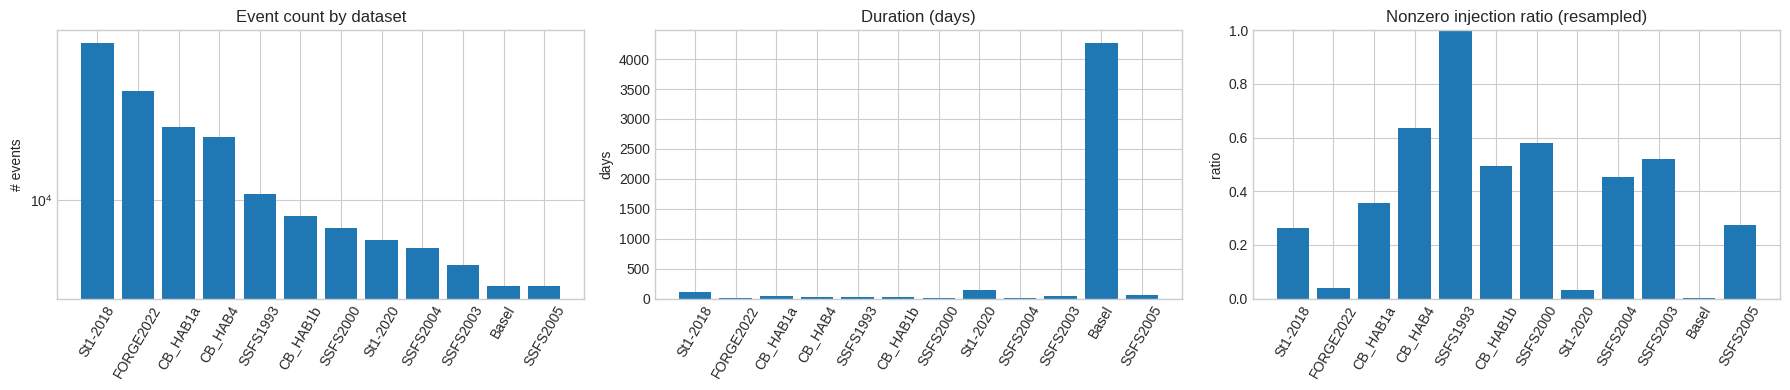

In [4]:
if len(summary_df) == 0:
    raise RuntimeError("No datasets discovered.")

plot_df = summary_df.sort_values("n_eq", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(plot_df["dataset"], plot_df["n_eq"])
axes[0].set_title("Event count by dataset")
axes[0].set_ylabel("# events")
axes[0].set_yscale("log")

axes[1].bar(plot_df["dataset"], plot_df["duration_day"])
axes[1].set_title("Duration (days)")
axes[1].set_ylabel("days")

axes[2].bar(plot_df["dataset"], plot_df["inj_nonzero_ratio_resampled"].fillna(0))
axes[2].set_title("Nonzero injection ratio (resampled)")
axes[2].set_ylabel("ratio")
axes[2].set_ylim(0, 1)

for ax in axes:
    ax.tick_params(axis="x", rotation=60)

plt.tight_layout()


## 5) Single dataset detailed visualization

Plot dataset: SSFS1993


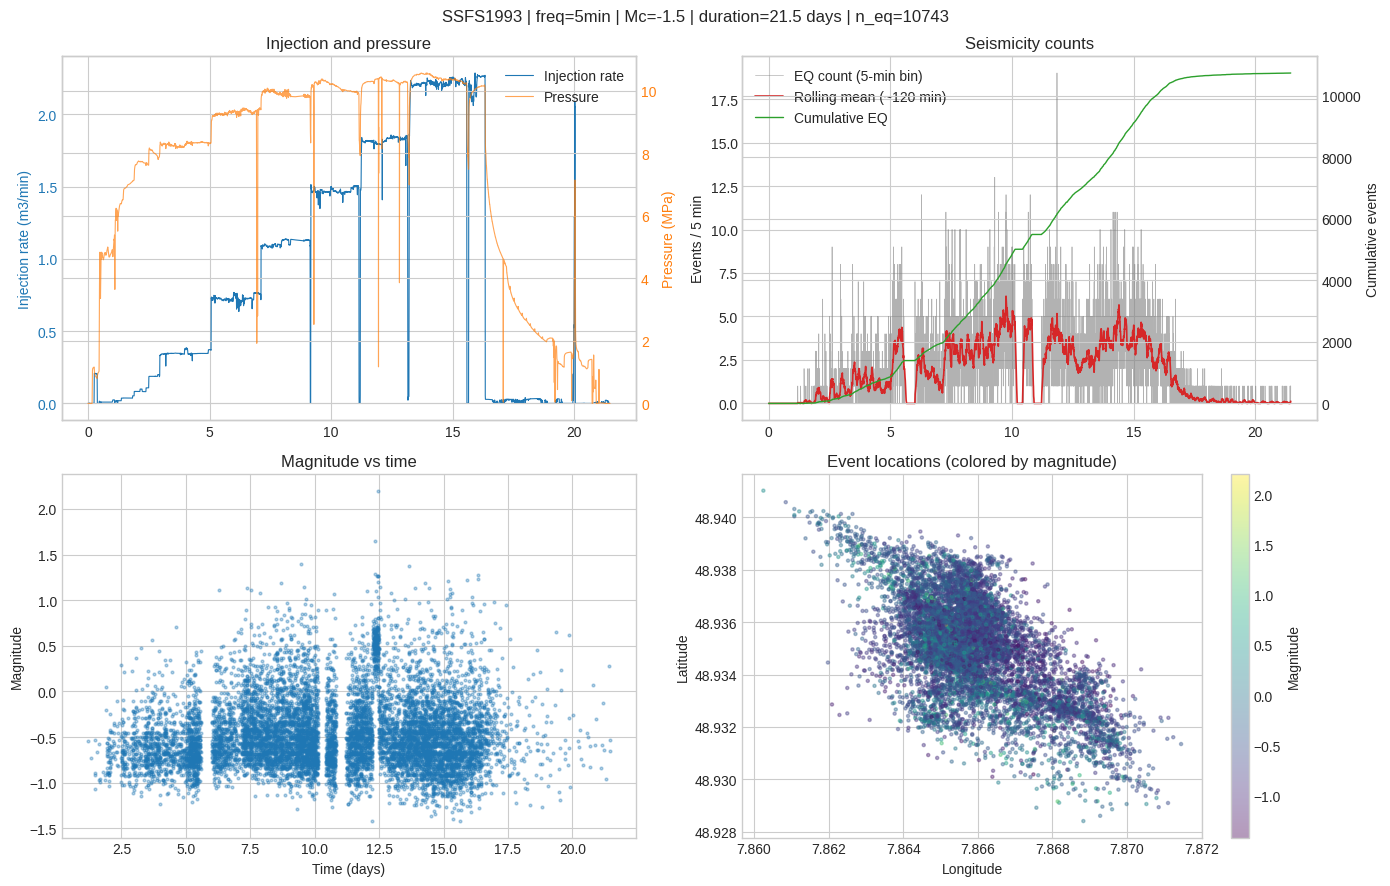

In [5]:
def load_processed_dataset(dataset: str):
    """Load processed EQ/injection files and summary metadata for a dataset."""
    base = DATA_ROOT / dataset / "processed"
    eq_path = base / f"{dataset}_eq_processed.csv"
    summary_path = base / f"{dataset}_summary.json"

    if not (eq_path.exists() and summary_path.exists()):
        raise FileNotFoundError(f"Processed files missing for {dataset}. Run the preprocessing cell first.")

    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    if "resample_freq_min" not in summary:
        raise KeyError("Missing required key 'resample_freq_min' in summary.")
    freq_min = int(summary["resample_freq_min"])
    inj_path = base / f"{dataset}_inj_{freq_min}min_processed.csv"

    if not inj_path.exists():
        raise FileNotFoundError(f"Injection file missing for {dataset}: expected {inj_path.name}")

    eq = pd.read_csv(eq_path)
    inj = pd.read_csv(inj_path)

    if "time_iso" not in eq.columns or "time_iso" not in inj.columns:
        raise KeyError("Both processed EQ and INJ files must contain 'time_iso'.")

    eq["time_iso"] = pd.to_datetime(eq["time_iso"], format="mixed", errors="raise", utc=True).dt.tz_convert(None)
    inj["time_iso"] = pd.to_datetime(inj["time_iso"], format="mixed", errors="raise", utc=True).dt.tz_convert(None)

    return eq, inj, summary


def plot_dataset_detail(dataset: str, smooth_window_min: int = 120, max_points: int = 12000):
    """Plot detailed processed injection and seismicity diagnostics for one dataset."""
    eq, inj, meta = load_processed_dataset(dataset)
    required_meta = ["resample_freq_min", "time_origin_iso", "resample_rule", "mc", "duration_day", "n_eq"]
    missing_meta = [k for k in required_meta if k not in meta]
    if missing_meta:
        raise KeyError(f"Missing required summary keys: {missing_meta}")

    freq_min = int(meta["resample_freq_min"])
    if freq_min <= 0:
        raise ValueError(f"resample_freq_min must be positive, got {freq_min}")
    smooth_bins = max(1, int(round(smooth_window_min / freq_min)))
    origin_ts = pd.to_datetime(meta["time_origin_iso"], format="mixed", errors="raise", utc=True).tz_convert(None)

    inj = inj.sort_values("time_iso").reset_index(drop=True)
    x_day = ((inj["time_iso"] - origin_ts) / pd.Timedelta(days=1)).astype(float)

    stride = max(1, len(inj) // max_points)
    inj_view = inj.iloc[::stride]
    x_day_view = x_day.iloc[::stride]

    eq_plot = eq.dropna(subset=["magnitude"]).copy()
    if len(eq_plot) > 50000:
        eq_plot = eq_plot.sample(50000, random_state=0).sort_values("time_iso")

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # (1) Injection + pressure
    ax0 = axes[0, 0]
    line_ir = ax0.plot(x_day_view, inj_view["inj_rate_m3_min"], color="tab:blue", linewidth=0.8, label="Injection rate")
    ax0.set_ylabel("Injection rate (m3/min)", color="tab:blue")
    ax0.tick_params(axis="y", labelcolor="tab:blue")

    ax0b = ax0.twinx()
    line_p = ax0b.plot(x_day_view, inj_view["pressure_mpa"], color="tab:orange", linewidth=0.8, alpha=0.7, label="Pressure")
    ax0b.set_ylabel("Pressure (MPa)", color="tab:orange")
    ax0b.tick_params(axis="y", labelcolor="tab:orange")

    ax0.set_title("Injection and pressure")
    handles = line_ir + line_p
    labels = [h.get_label() for h in handles]
    ax0.legend(handles, labels, loc="upper right")

    # (2) EQ count + cumulative count
    ax1 = axes[0, 1]
    eq_count = inj["eq_count"]
    eq_roll = eq_count.rolling(smooth_bins, min_periods=1).mean()

    line_eq = ax1.plot(x_day, eq_count, color="tab:gray", linewidth=0.5, alpha=0.6, label=f"EQ count ({freq_min}-min bin)")
    line_roll = ax1.plot(x_day, eq_roll, color="tab:red", linewidth=1.2, label=f"Rolling mean (~{smooth_window_min} min)")
    ax1.set_ylabel(f"Events / {freq_min} min")

    ax1b = ax1.twinx()
    line_cum = ax1b.plot(x_day, inj["eq_cum_count"], color="tab:green", linewidth=1.0, label="Cumulative EQ")
    ax1b.set_ylabel("Cumulative events")

    ax1.set_title("Seismicity counts")
    handles = line_eq + line_roll + line_cum
    labels = [h.get_label() for h in handles]
    ax1.legend(handles, labels, loc="upper left")

    # (3) Magnitude-time scatter
    ax2 = axes[1, 0]
    if len(eq_plot) > 0:
        eq_day = ((eq_plot["time_iso"] - origin_ts) / pd.Timedelta(days=1)).astype(float)
        ax2.scatter(eq_day, eq_plot["magnitude"], s=4, alpha=0.35)
    ax2.set_title("Magnitude vs time")
    ax2.set_xlabel("Time (days)")
    ax2.set_ylabel("Magnitude")

    # (4) Location map if coordinates available, otherwise magnitude histogram
    ax3 = axes[1, 1]
    eq_loc = eq.dropna(subset=["longitude", "latitude", "magnitude"]).copy()
    if len(eq_loc) > 0:
        if len(eq_loc) > 50000:
            eq_loc = eq_loc.sample(50000, random_state=0)
        sc = ax3.scatter(
            eq_loc["longitude"],
            eq_loc["latitude"],
            c=eq_loc["magnitude"],
            cmap="viridis",
            s=5,
            alpha=0.4,
        )
        ax3.set_xlabel("Longitude")
        ax3.set_ylabel("Latitude")
        ax3.set_title("Event locations (colored by magnitude)")
        cbar = fig.colorbar(sc, ax=ax3)
        cbar.set_label("Magnitude")
    else:
        ax3.hist(eq["magnitude"].dropna(), bins=50, edgecolor="black")
        ax3.set_xlabel("Magnitude")
        ax3.set_ylabel("Count")
        ax3.set_title("Magnitude histogram")

    fig.suptitle(
        f"{dataset} | freq={meta['resample_rule']} | Mc={meta['mc']} | duration={meta['duration_day']:.1f} days | n_eq={meta['n_eq']}",
        fontsize=12,
    )
    fig.tight_layout()
    plt.show()


PLOT_DATASET = "SSFS1993"
if PLOT_DATASET not in DATASETS and len(DATASETS) > 0:
    PLOT_DATASET = DATASETS[0]

print(f"Plot dataset: {PLOT_DATASET}")
plot_dataset_detail(PLOT_DATASET, smooth_window_min=120)





## 6) Optional: quick browse several datasets

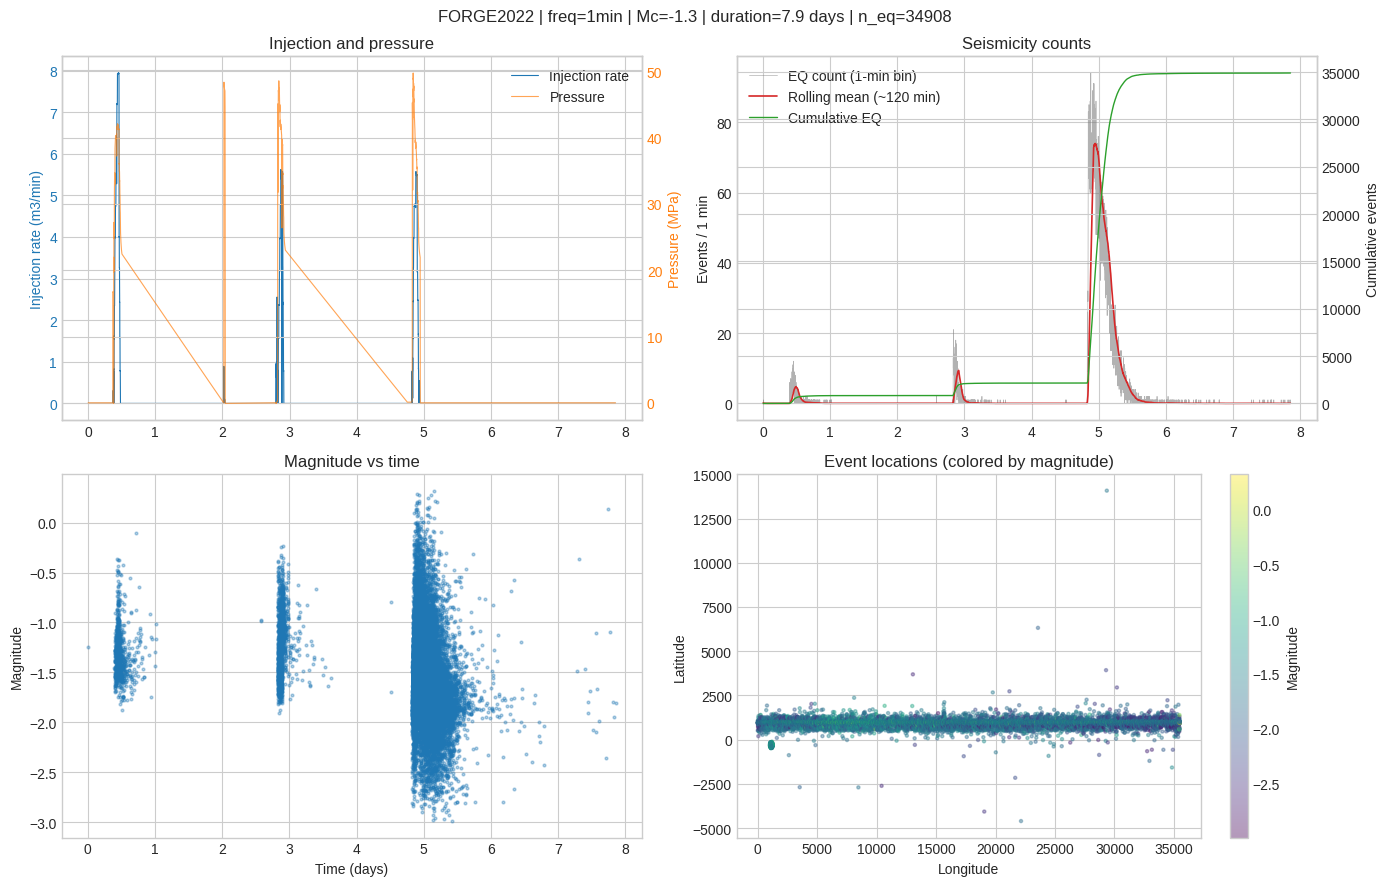

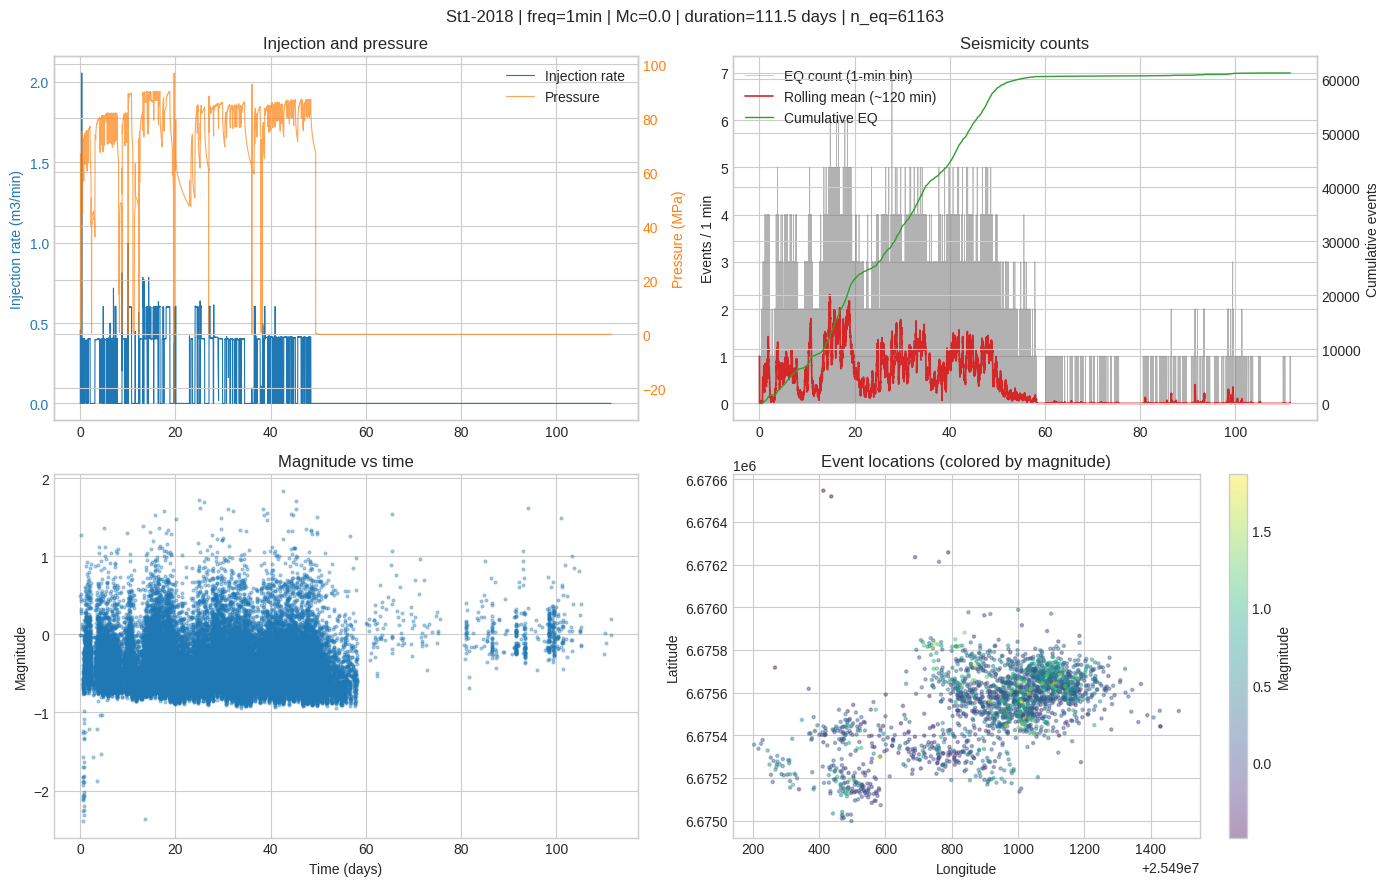

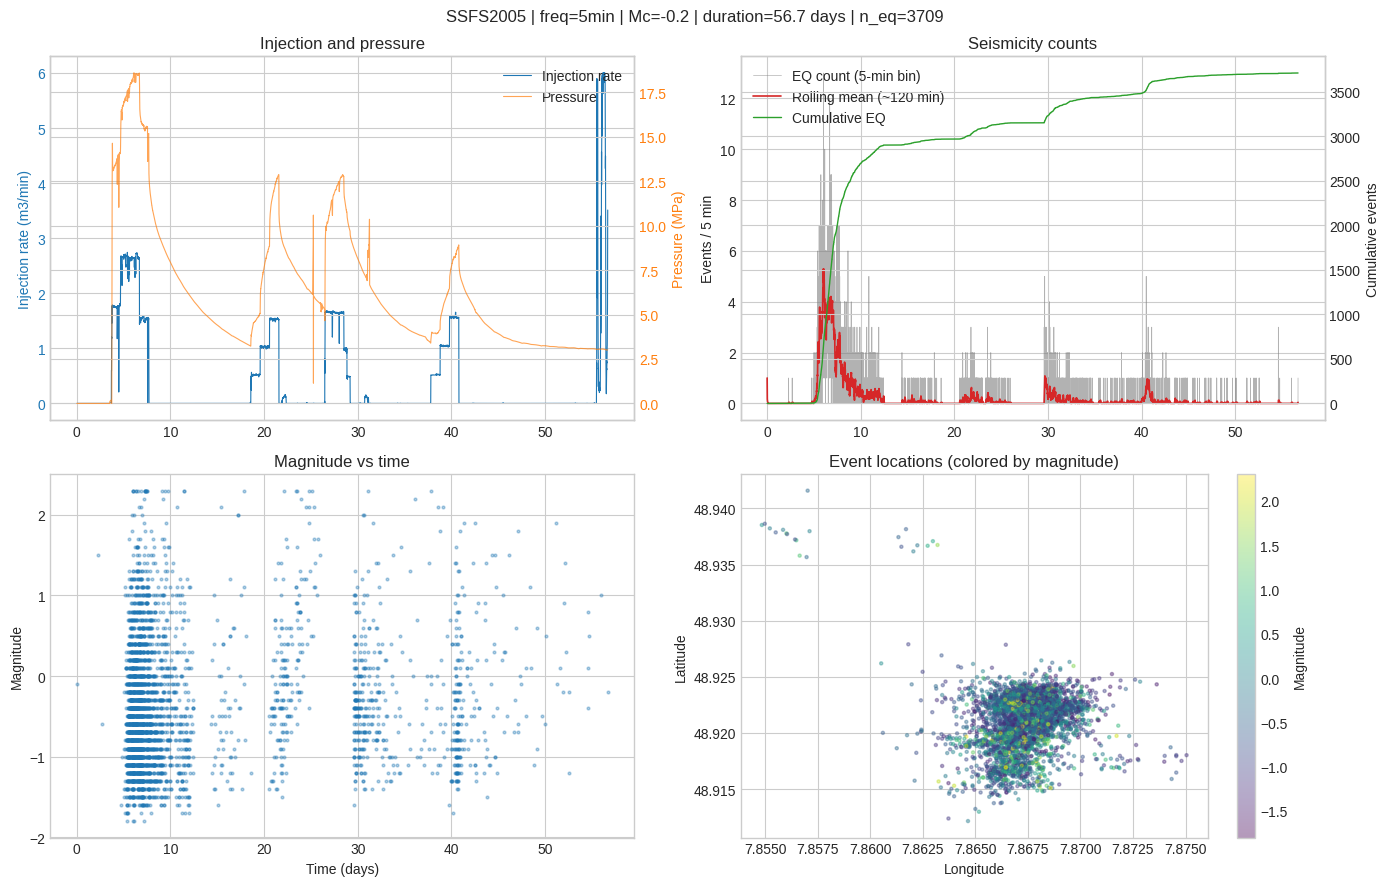

In [6]:
PLOT_DATASETS = ["FORGE2022", "St1-2018", "SSFS2005"]

for ds in PLOT_DATASETS:
    if ds in DATASETS:
        plot_dataset_detail(ds, smooth_window_min=120)


## 7) Export check

In [7]:
for ds in DATASETS:
    base = DATA_ROOT / ds / "processed"
    files = sorted([p.name for p in base.glob("*")]) if base.exists() else []
    print(f"[{ds}]")
    for f in files:
        print(f"  - {f}")


[Basel]
  - Basel_eq_processed.csv
  - Basel_inj_1min_processed.csv
  - Basel_summary.json
[CB_HAB1a]
  - CB_HAB1a_eq_processed.csv
  - CB_HAB1a_inj_1min_processed.csv
  - CB_HAB1a_summary.json
[CB_HAB1b]
  - CB_HAB1b_eq_processed.csv
  - CB_HAB1b_inj_1min_processed.csv
  - CB_HAB1b_summary.json
[CB_HAB4]
  - CB_HAB4_eq_processed.csv
  - CB_HAB4_inj_1min_processed.csv
  - CB_HAB4_summary.json
[FORGE2022]
  - FORGE2022_eq_processed.csv
  - FORGE2022_inj_1min_processed.csv
  - FORGE2022_summary.json
[SSFS1993]
  - SSFS1993_eq_processed.csv
  - SSFS1993_inj_5min_processed.csv
  - SSFS1993_summary.json
[SSFS2000]
  - SSFS2000_eq_processed.csv
  - SSFS2000_inj_1min_processed.csv
  - SSFS2000_inj_5min_processed.csv
  - SSFS2000_summary.json
[SSFS2003]
  - SSFS2003_eq_processed.csv
  - SSFS2003_inj_1min_processed.csv
  - SSFS2003_inj_5min_processed.csv
  - SSFS2003_summary.json
[SSFS2004]
  - SSFS2004_eq_processed.csv
  - SSFS2004_inj_1min_processed.csv
  - SSFS2004_inj_5min_processed.csv
  -